In [ ]:
import pandas as pd
import os 
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.tree import plot_tree
from sklearn.inspection import permutation_importance

In [2]:
df = pd.read_csv('../banco_fenotipos_conformal.csv') # Load the phenotypic data
df = df.drop(columns=['id','samplefilename', 'CP1','CP2','CP3','CP4','CP5','CP6']) # remove the id from the table
colunas_categoricas = ['fumo', 'raca_cor', 'conjugal3', 'trabalho2', 'bebem2']
df = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True, dtype=int) # Turns the categorical columns into 0 and 1

In [3]:
df.columns

Index(['hb_g_dl', 'glicose_mg_dl', 'sexo', 'idade', 'faixa_etaria', 'imc',
       'imc_cat4_aferido', 'imc_cat_aferido', 'ep', 'obesidade', 'ccm',
       'obes_central', 'cc_estat', 'cc_estat_cat', 'medDM_bioq', 'diabetes2',
       'HOMA_IR', 'HOMA_cat', 'pas_final', 'pad_final', 'medHAS_bioq', 'has2',
       'col_nao_hdlc_mg_dl', 'colnaohdl_cat', 'fumo_fumante', 'fumo_nunca',
       'fumo_não respondeu', 'raca_cor_branca', 'raca_cor_indígena',
       'raca_cor_não respondeu', 'raca_cor_outras', 'raca_cor_parda',
       'raca_cor_preta', 'conjugal3_casado/un. estavel',
       'conjugal3_separado/desq/divorc', 'conjugal3_solteiro',
       'conjugal3_viuvo', 'trabalho2_estudante', 'trabalho2_nÃ£o trabalha',
       'trabalho2_trabalha', 'bebem2_NS/NR', 'bebem2_atÃ© 3x semana',
       'bebem2_nÃ£o bebe'],
      dtype='str')

In [4]:
nrespondeu = [coluna for coluna in df.columns if 'respondeu' in coluna]
df = df.drop(columns=nrespondeu)

In [101]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance


def extrair_frequencia_estabilidade_grafo(
    df, alvos, num_trees=500, iteracoes=50, fracao_amostra=0.5, q=3
):
    """Extrai a frequência de estabilidade das arestas baseado no artigo

    Fellinghauer et al. (2013).

    Parâmetros:
    - q: Número de top variáveis com maior importância que serão selecionadas
         em cada iteração (frequência binária).
    """
    # Matriz inicializada com zeros
    matriz_estabilidade = pd.DataFrame(
        index=alvos, columns=df.columns, dtype=np.float64
    ).fillna(0.0)

    for target in alvos:
        print(f"Rodando a variável {target}")
        nopcoes = df[target].nunique()
        df_alvo = df.dropna(subset=[target])

        for i in range(iteracoes):
            df_sub = df_alvo.sample(frac=fracao_amostra, random_state=i)

            X = df_sub.drop(columns=[target])
            y = df_sub[target]

            if nopcoes > 5:
                modelorf = RandomForestRegressor(
                    n_estimators=num_trees,
                    max_features=0.3,
                    max_depth=8,
                    n_jobs = -1,
                    bootstrap=False,
                )
            else:
                modelorf = RandomForestClassifier(
                    n_estimators=num_trees,
                    max_features=0.3,
                    max_depth=8,
                    bootstrap=False,
                    n_jobs = -1,
                )

            modelorf.fit(X, y)

            # Calcula o Permutation Importance
            resultado_permutacao = permutation_importance(
                modelorf, X, y, n_repeats=3, random_state=i, n_jobs=-1
            )
            importancias = resultado_permutacao.importances_mean

            # --- MÁGICA DO ARTIGO: SELEÇÃO BINÁRIA ---
            # Criamos uma série com as importâncias mapeadas nas colunas corretas
            importancias_series = pd.Series(importancias, index=X.columns)

            # Descobrimos quais são as 'q' maiores variáveis dessa rodada
            top_q_variaveis = importancias_series.nlargest(q).index

            # Somamos 1 APENAS para quem entrou no TOP Q (voto binário)
            matriz_estabilidade.loc[target, top_q_variaveis] += 1.0

        # No final, dividimos pelas iterações para obter a FREQUÊNCIA (entre 0 e 1)
        matriz_estabilidade.loc[target] = (
            matriz_estabilidade.loc[target] / iteracoes
        )

    return matriz_estabilidade

In [ ]:
%%time
q= 20
matriz_final = extrair_importancias_grafo(df, df.columns, 300, 8,0.4,q)


Rodando a variável hb_g_dl
Rodando a variável glicose_mg_dl
Rodando a variável sexo
Rodando a variável idade


In [87]:
matriz_numpy = matriz_final.to_numpy()

matriz_min = np.minimum(matriz_numpy,matriz_numpy.T)

matriz_final = pd.DataFrame(
    matriz_min, index=matriz_final.index, columns=matriz_final.columns
)

In [77]:
matriz_final

,hb_g_dl,glicose_mg_dl,sexo,idade,faixa_etaria,imc,imc_cat4_aferido,imc_cat_aferido,ep,obesidade,...,conjugal3_casado/un. estavel,conjugal3_separado/desq/divorc,conjugal3_solteiro,conjugal3_viuvo,trabalho2_estudante,trabalho2_nÃ£o trabalha,trabalho2_trabalha,bebem2_NS/NR,bebem2_atÃ© 3x semana,bebem2_nÃ£o bebe
hb_g_dl,0.000000,0.025347,0.150278,0.004596,0.000000,0.006553,0.000000,0.000000,0.00000,0.000000,...,0.000069,0.000903,0.000208,0.000000,0.000000,0.001319,0.001111,0.000000,0.000625,0.000833
glicose_mg_dl,0.025347,0.000000,0.003413,0.005883,0.000000,0.003713,0.000000,0.000000,0.00000,0.000000,...,0.000278,0.000000,0.000069,0.000000,0.000000,0.000000,0.000000,0.000000,0.000641,0.000887
sexo,0.150278,0.003413,0.000000,0.000514,0.000000,-0.000139,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000486
idade,0.004596,0.005883,0.000514,0.000000,0.357292,0.009612,0.029307,0.000000,0.00000,0.000000,...,0.001037,0.001162,0.007724,0.003321,0.004370,0.000486,0.004236,0.000208,0.000436,0.000751
faixa_etaria,0.000000,0.000000,0.000000,0.357292,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,-0.000278,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imc,0.006553,0.003713,-0.000139,0.009612,0.000000,0.000000,0.110693,0.000000,0.00000,0.000000,...,0.000000,0.001597,0.000278,0.000208,0.000000,0.000000,0.000000,0.000000,0.000487,0.000498
imc_cat4_aferido,0.000000,0.000000,0.000000,0.029307,0.000000,0.110693,0.000000,0.000000,0.00000,0.000000,...,-0.000208,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imc_cat_aferido,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.37101,0.143066,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ep,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.371010,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
obesidade,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.143066,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [97]:
# --- CÁLCULO DO LIMIAR DO ARTIGO ---
p = len(df.columns)  # Número total de variáveis no seu dataset
P = (p * (p - 1)) / 2  # Total de arestas possíveis em um grafo NÃO-DIRECIONADO
EV = 5 # Número esperado de falsos positivos que você tolera no grafo todo

# Fórmula do artigo isolando o limiar (pi_thr)
IMPORT_MIN = 0.5 + ((q**2) / (2 * EV * P))

print(f"Número de variáveis (p): {p}")
print(f"Arestas possíveis (P): {P}")
print(f"Limiar de Estabilidade Matemático (IMPORT_MIN): {IMPORT_MIN:.4f}")

Número de variáveis (p): 41
Arestas possíveis (P): 820.0
Limiar de Estabilidade Matemático (IMPORT_MIN): 0.5000


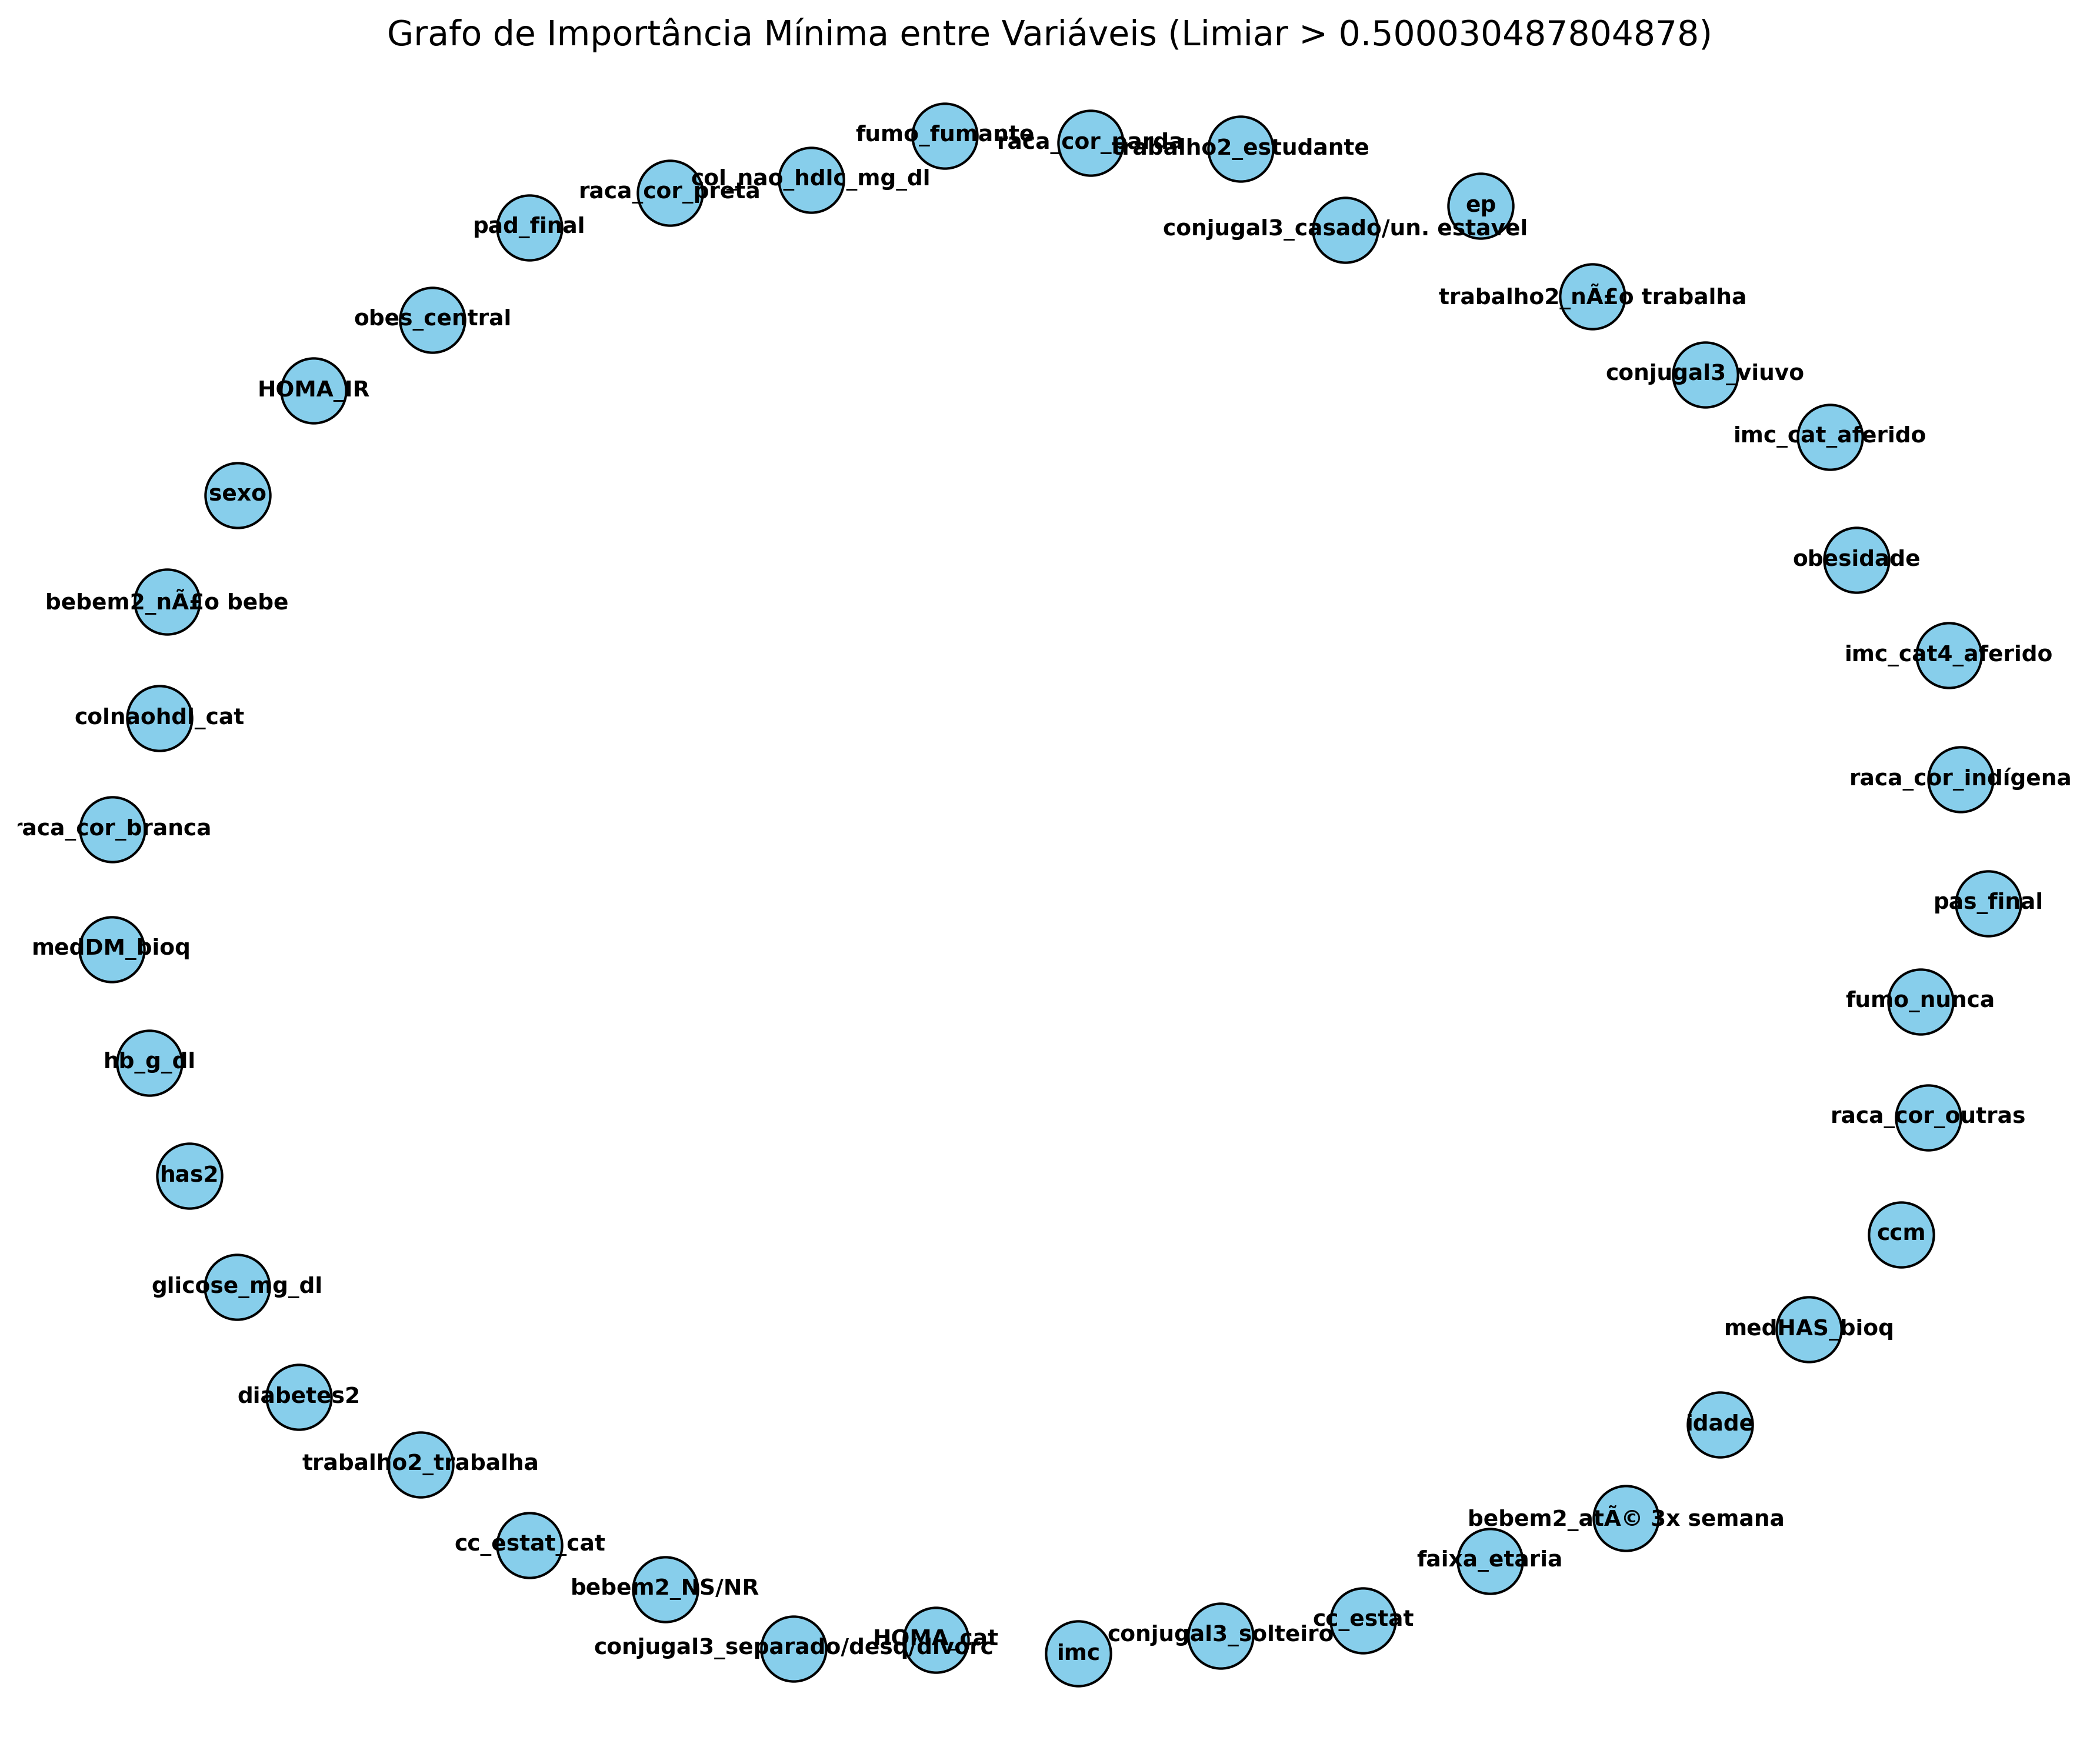

In [98]:
Grafo = nx.from_pandas_adjacency(matriz_final, create_using=nx.Graph)

arestas_para_remover = [
    (u, v)
    for u, v, d in Grafo.edges(data=True)
    if d["weight"] <= IMPORT_MIN
]
Grafo.remove_edges_from(arestas_para_remover)

# Grafo.remove_nodes_from(list(nx.isolates(Grafo)))

# --- ESTILIZAÇÃO DO GRAFO ---
plt.figure(figsize=(12, 10), dpi=300)

pos = nx.spring_layout(Grafo, weight='weight', iterations=150, k= 0.5)

pesos = np.array([d["weight"] for u, v, d in Grafo.edges(data=True)])

nx.draw_networkx_nodes(
    Grafo, pos, node_size=700, node_color="skyblue", edgecolors="black"
)

# if len(pesos) > 0:
#     espessura = (pesos/pesos.max())*5
# else: 
espessura = 5
nx.draw_networkx_edges(
    Grafo, pos, width=espessura, edge_color="gray", alpha=0.7, arrows=False
)


# Desenha os Nomes das Variáveis
nx.draw_networkx_labels(Grafo, pos, font_size=9, font_weight="bold")

plt.title(
    f"Grafo de Importância Mínima entre Variáveis (Limiar > {IMPORT_MIN})",
    fontsize=14,
)
plt.axis("off")
plt.tight_layout()
plt.show()